In [3]:
# Set the config path here, need to restart the notebook after changing this
config_file = '../configs/loci_example.yaml'

# Imports

In [5]:
import os

import pandas as pd
import matplotlib.pyplot as plt

import spice
spice.load_config(config_file)
from spice import config, directories, data_loaders, plot
from spice.data_loaders import resolve_copynumber_file, load_final_events
from spice.utils import open_pickle
from spice.tsg_og.detection import convolution_simulation_per_ls

CHROM_LENS = data_loaders.load_chrom_lengths()
CHROMS = list(CHROM_LENS.keys())
CENTROMERES = data_loaders.load_centromeres()

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
output_dir = f"../results/{config['name']}/loci_of_selection"
detection_assignment = 'detection' # choose between detection or assignment

# Plot whole chromosome

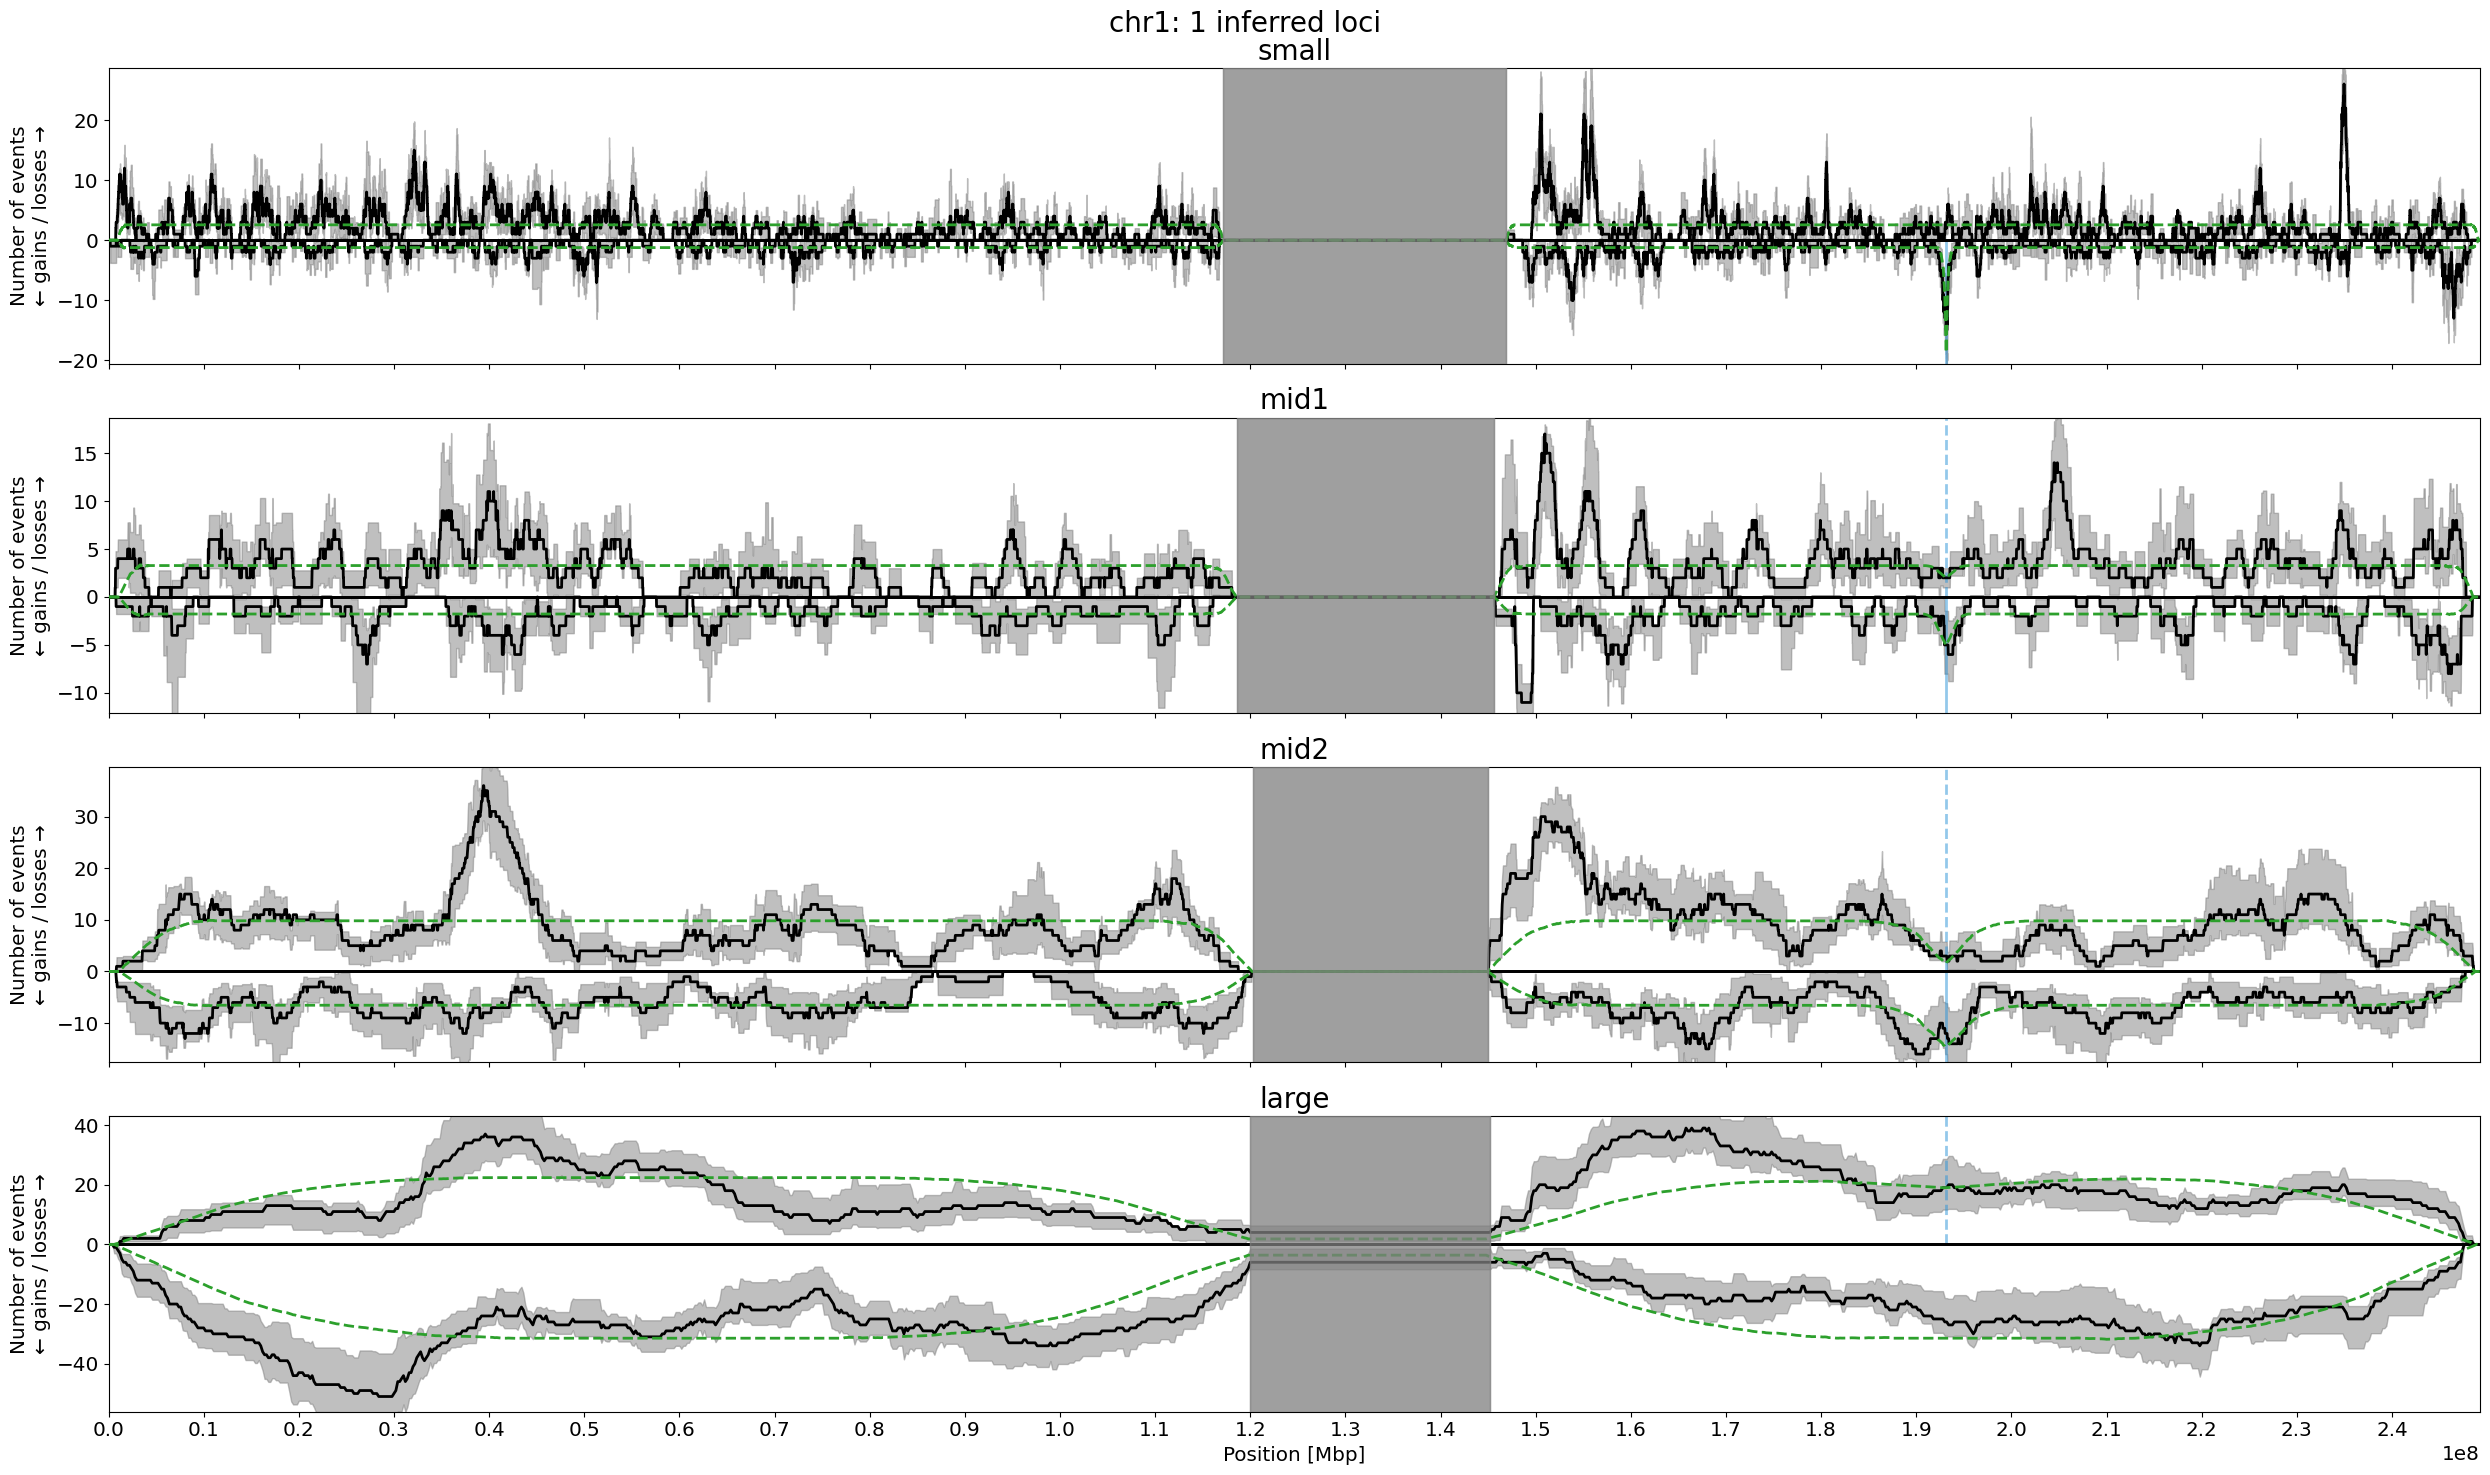

In [11]:
cur_chrom = 'chr1'

data_per_ls = open_pickle(os.path.join(output_dir, 'data_per_length_scale',  f'{cur_chrom}.pickle'))
selection_points = open_pickle(os.path.join(output_dir, detection_assignment, cur_chrom, f'final_selection_points.pickle'))

simulated_conv = convolution_simulation_per_ls(
    cur_chrom, data_per_ls, selection_points)
fig, axs = plt.subplots(figsize=(25, 15), nrows=4, ncols=1, sharex=True)
plot.plot_tsg_og_results(
    cur_chrom, data_per_ls, simulated_conv=simulated_conv,
    plot_signal_bounds=True, fig=fig,
    final_selection_points=selection_points);
plt.show()

# Plot single locus

In [36]:
final_loci_df = pd.read_csv(
    os.path.join(config['directories']['results_dir'], config['name'], f'final_loci_{detection_assignment}.tsv'),
    sep='\t', index_col=0)
final_loci_df.head()

,chrom,pos,rank_on_chrom,width,pos_total,start,end,fitness_small_gain,fitness_small_loss,fitness_mid1_gain,fitness_mid1_loss,fitness_mid2_gain,fitness_mid2_loss,fitness_large_gain,fitness_large_loss,type,added_events,p_value
0,chr1,1.931448e+08,0,119043.25,1.931448e+08,1.930853e+08,1.932044e+08,0.0,14.150632,-0.428954,1.838618,-0.921988,1.355605,-0.165917,0.000000,TSG,23.220292,0.009901
1,chr2,1.418896e+08,0,119043.25,3.911402e+08,1.418301e+08,1.419491e+08,0.0,55.868200,0.000000,3.806284,-0.647273,0.000000,-0.069951,0.726755,TSG,54.058511,0.009901


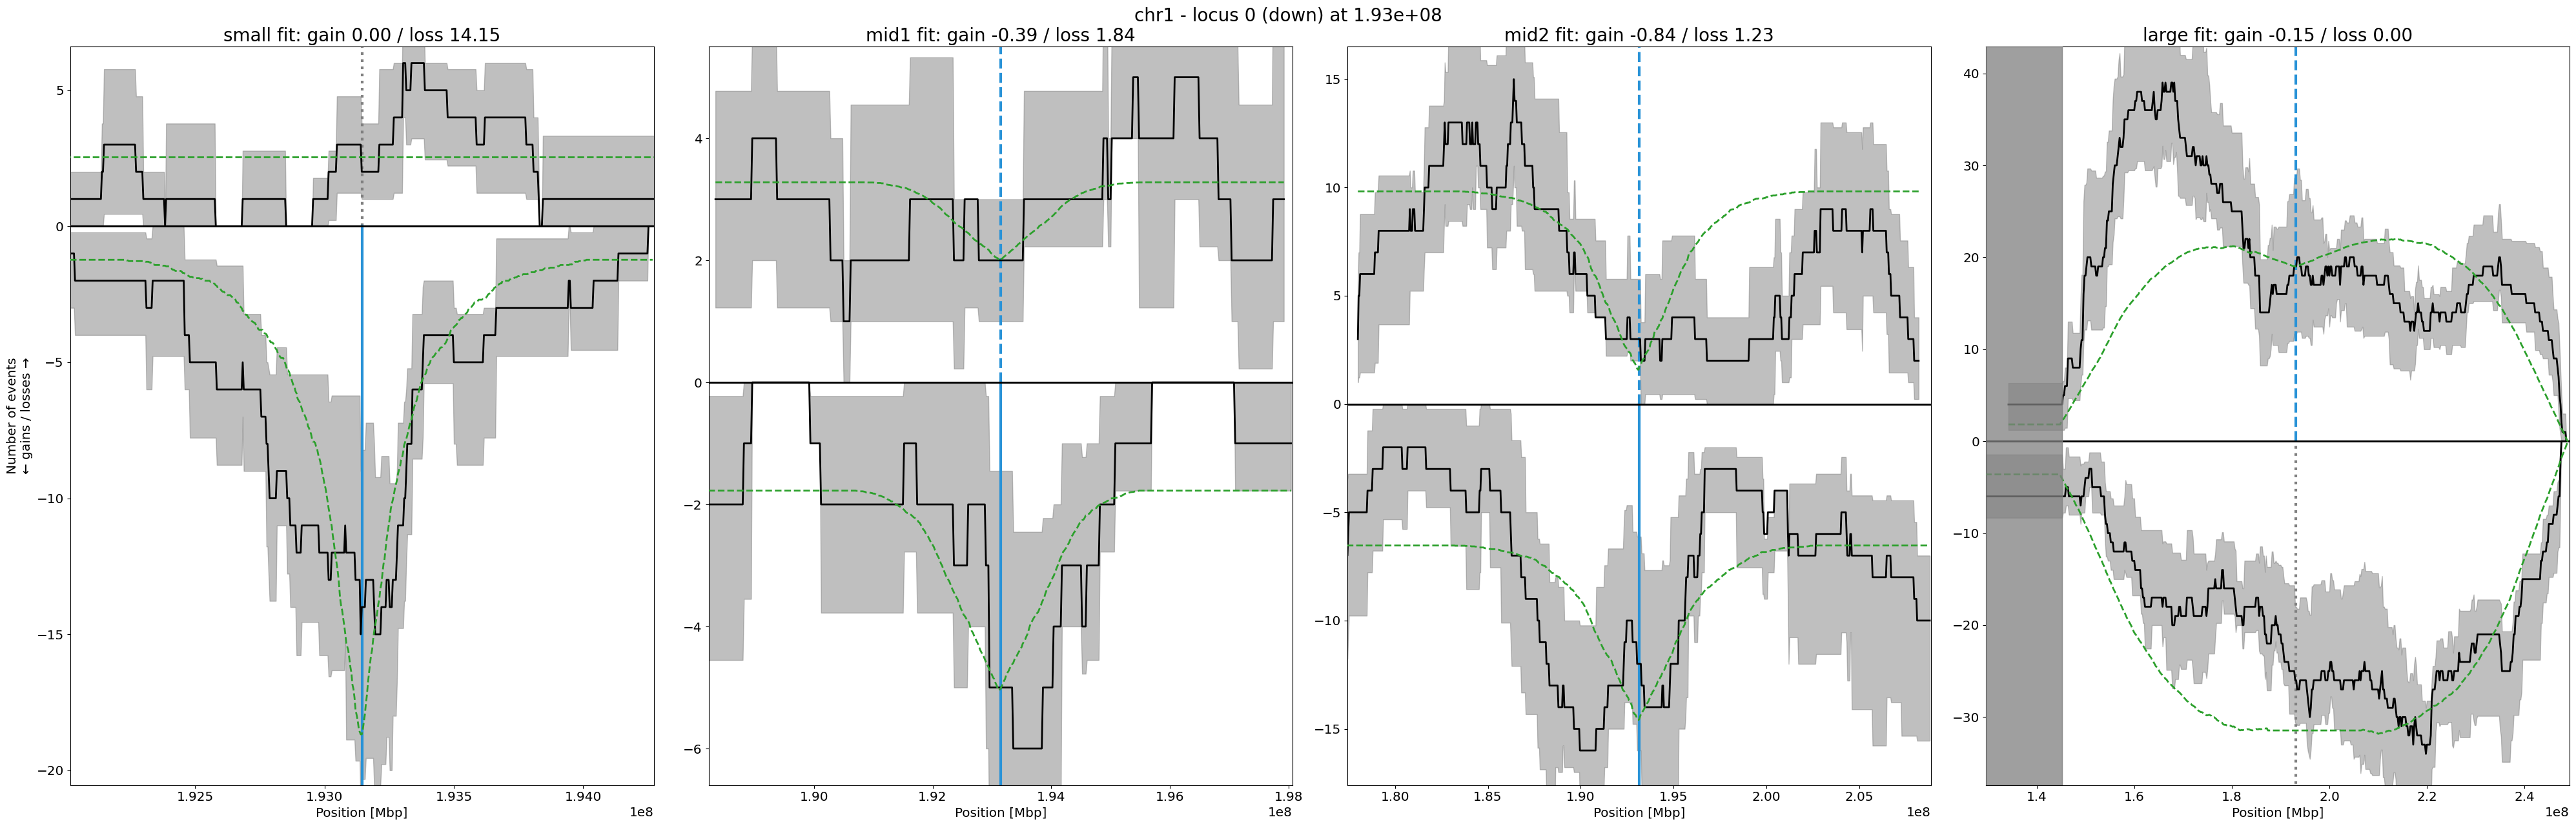

In [37]:
loci_index = 1

data_per_ls = open_pickle(os.path.join(output_dir, 'data_per_length_scale',  f'{cur_chrom}.pickle'))
selection_points = open_pickle(os.path.join(output_dir, detection_assignment, cur_chrom, f'final_selection_points.pickle'))

simulated_conv = convolution_simulation_per_ls(
    cur_chrom, data_per_ls, selection_points)

cluster_i = final_loci_df.loc[loci_index, 'rank_on_chrom']
fig, axs = plt.subplots(figsize=(40, 13), nrows=1, ncols=4)
fig, axs = plot.plot_tsg_og_results(
    cur_chrom, data_per_ls, simulated_conv=simulated_conv,
    cluster_i=cluster_i, relative_window_size=3,
    orientation='v', fig=fig, xlim=(1e7, 5e7),
    final_selection_points=selection_points,
    )

In [16]:
final_loci_df

,chrom,pos,rank_on_chrom,width,pos_total,start,end,fitness_small_gain,fitness_small_loss,fitness_mid1_gain,fitness_mid1_loss,fitness_mid2_gain,fitness_mid2_loss,fitness_large_gain,fitness_large_loss,type,added_events,p_value
0,chr1,1.931448e+08,0,119043.25,1.931448e+08,1.930853e+08,1.932044e+08,0.0,14.150632,-0.428954,1.838618,-0.921988,1.355605,-0.165917,0.000000,TSG,23.220292,0.009901
1,chr2,1.418896e+08,0,119043.25,3.911402e+08,1.418301e+08,1.419491e+08,0.0,55.868200,0.000000,3.806284,-0.647273,0.000000,-0.069951,0.726755,TSG,54.058511,0.009901
